<a href="https://colab.research.google.com/github/johnlwilson223-web/Python-projects/blob/main/Week6_KMeans_PCA_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Assignment
## K-Means Clustering and PCA
John Wilson



In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X = iris.data

print(X.shape)

(150, 4)


In [3]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[681.3705999999996, 152.34795176035797, 78.851441426146, 57.22847321428572, 46.46117267267268, 39.03998724608725, 34.305815295815314, 30.132440554614483, 28.29063524195104, 25.970929851803426]


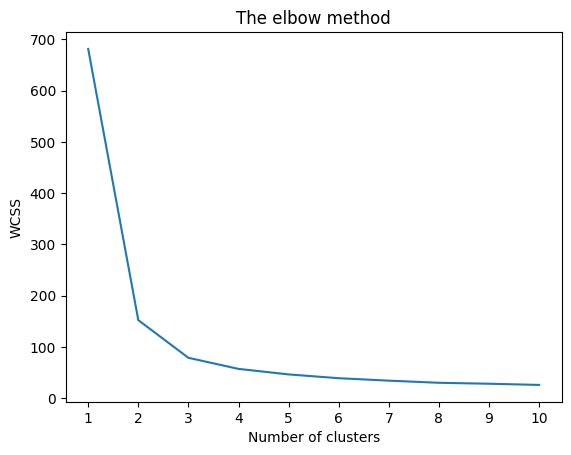

In [4]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

### Elbow Method Result

The elbow occurs at approximately K = 3. After three clusters, the decrease in WCSS becomes much smaller. Therefore, 3 is an appropriate number of clusters for the Iris dataset.

# Part 2: PCA and Logistic Regression on MNIST

This section compares Logistic Regression on the MNIST dataset before and after PCA dimensionality reduction.

In [5]:
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [6]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (56000, 784)
Testing data: (14000, 784)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [9]:
logisticRegr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

start_time = time.time()

logisticRegr.fit(X_train_scaled, y_train)

end_time = time.time()

time_without_pca = end_time - start_time

predictions = logisticRegr.predict(X_test_scaled)
accuracy_without_pca = accuracy_score(y_test, predictions)

print("Time without PCA:", round(time_without_pca, 2), "seconds")
print("Accuracy without PCA:", round(accuracy_without_pca, 4))

Time without PCA: 66.52 seconds
Accuracy without PCA: 0.9154


In [10]:
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of features after PCA:", X_train_pca.shape[1])

Original number of features: 784
Number of features after PCA: 330


In [11]:
logisticRegr_pca = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

start_time = time.time()

logisticRegr_pca.fit(X_train_pca, y_train)

end_time = time.time()

time_with_pca = end_time - start_time

predictions_pca = logisticRegr_pca.predict(X_test_pca)
accuracy_with_pca = accuracy_score(y_test, predictions_pca)

print("Time with PCA:", round(time_with_pca, 2), "seconds")
print("Accuracy with PCA:", round(accuracy_with_pca, 4))

Time with PCA: 61.02 seconds
Accuracy with PCA: 0.922


In [12]:
print("WITHOUT PCA")
print("Number of features: 784")
print("Training time:", round(time_without_pca, 2), "seconds")
print("Accuracy:", round(accuracy_without_pca * 100, 2), "%")

print("\nWITH PCA")
print("Number of features:", X_train_pca.shape[1])
print("Training time:", round(time_with_pca, 2), "seconds")
print("Accuracy:", round(accuracy_with_pca * 100, 2), "%")

print("\nTime saved:", round(time_without_pca - time_with_pca, 2), "seconds")

WITHOUT PCA
Number of features: 784
Training time: 66.52 seconds
Accuracy: 91.54 %

WITH PCA
Number of features: 330
Training time: 61.02 seconds
Accuracy: 92.2 %

Time saved: 5.49 seconds


## Conclusion

PCA reduced the MNIST dataset from 784 features to 330 features while retaining 95% of the variance. Without PCA, Logistic Regression took 66.52 seconds to train and achieved an accuracy of 91.54%. After applying PCA, training took 61.02 seconds and achieved an accuracy of 92.20%.

In this test, PCA reduced the Logistic Regression training time by 5.50 seconds while also slightly improving the accuracy. This demonstrates how dimensionality reduction can reduce the amount of data that the model needs to process while maintaining strong classification performance.